# CIFAR-10 V.1
The CIFAR10 dataset contains 60,000 color images in 10 classes, with 6,000 images in each class. The dataset is divided into 50,000 training images and 10,000 testing images. The classes are mutually exclusive and there is no overlap between them

### required modules

In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras import datasets, layers, models, optimizers

### constants

In [3]:
IMG_CHANNELS = 3
IMG_ROWS = 32
IMG_COLS = 32
BATCH_SIZE = 128
EPOCHS = 20
CLASSES = 10
VERBOSE = 1
VALIDATION_SPLIT = 0.2
OPTIM = tf.keras.optimizers.RMSprop()


2026-02-04 10:28:26.189681: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### load the dataset

In [4]:
(X_train, Y_train), (X_test,Y_test) = datasets.cifar10.load_data()

print("X_train: " + str(X_train.shape))
print("Y_train: " + str(Y_train.shape))
print("X_test: " + str(X_test.shape))
print("Y_test: " + str(Y_test.shape))

X_train: (50000, 32, 32, 3)
Y_train: (50000, 1)
X_test: (10000, 32, 32, 3)
Y_test: (10000, 1)


/home/maddalena/venv312/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


### normalize the datasets

In [5]:
X_train = X_train / 255.0
X_test = X_test / 255.0

### one-hot representation of the labels

In [6]:
Y_train = tf.keras.utils.to_categorical(Y_train, 10)
Y_test = tf.keras.utils.to_categorical(Y_test, 10)

### display some images

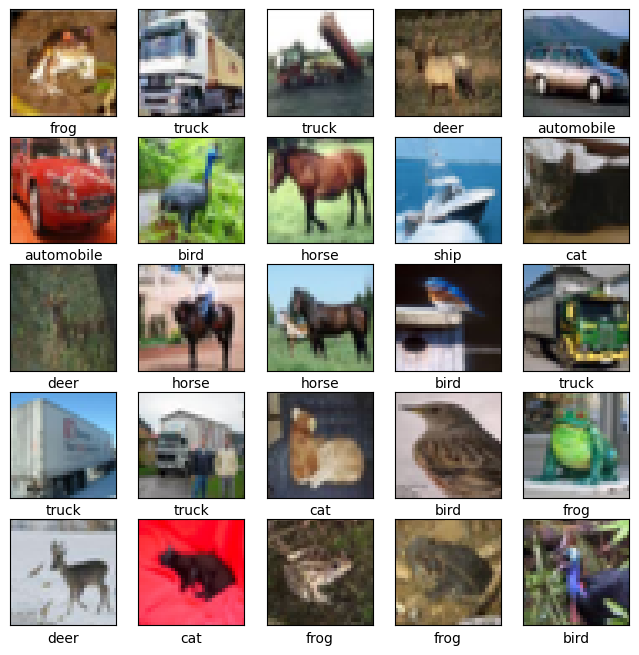

In [7]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(8,8))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[np.argmax(Y_train[i])])
plt.show()

### define the convnet

In [8]:
def build(input_shape, classes):
    model = models.Sequential()
    model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape))
    model.add(layers.MaxPool2D(pool_size=(2,2)))
    model.add(layers.Dropout(0.25))
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu')) # fully connected
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(classes, activation='softmax'))
    return model


### build the model

In [9]:
model = build((IMG_ROWS, IMG_COLS, IMG_CHANNELS), CLASSES)
model.summary()

/home/maddalena/venv312/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,686,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,692,938 (14.09 MB)

 Trainable params: 3,692,938 (14.09 MB)

 Non-trainable params: 0 (0.00 B)

### train the model

In [10]:
callbacks = [tf.keras.callbacks.TensorBoard(log_dir='./logs/cifar10/scalars/v1')]

model.compile(
    loss='categorical_crossentropy', 
    optimizer=OPTIM, 
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    Y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=VALIDATION_SPLIT,
    callbacks=callbacks,
    verbose=VERBOSE
)






Epoch 1/20


2026-02-04 10:28:29.793871: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 491520000 exceeds 10% of free system memory.


313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 108ms/step - accuracy: 0.3743 - loss: 1.7559 - val_accuracy: 0.4547 - val_loss: 1.5818
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 102ms/step - accuracy: 0.5038 - loss: 1.3998 - val_accuracy: 0.4951 - val_loss: 1.4252
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 101ms/step - accuracy: 0.5501 - loss: 1.2703 - val_accuracy: 0.5806 - val_loss: 1.2086
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 100ms/step - accuracy: 0.5816 - loss: 1.1791 - val_accuracy: 0.6067 - val_loss: 1.1365
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 99ms/step - accuracy: 0.6080 - loss: 1.1076 - val_accuracy: 0.6300 - val_loss: 1.0807
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 100ms/step - accuracy: 0.6374 - loss: 1.0400 - val_accuracy: 0.5755 - val_loss: 1.2244
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 100ms/step - accuracy: 0.6580 - loss: 0.9775 - val_accuracy: 0.6389 - val_loss: 1.0395
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 99ms/step - accuracy: 0.6770 - loss: 0.9225 - val_a

### create the history dataframe

In [11]:
history_df = pd.DataFrame(history.history)
history_df['epoch'] = history.epoch
history_df.tail()

,accuracy,loss,val_accuracy,val_loss,epoch
15,0.796500,0.585141,0.6828,0.963379,15
16,0.805475,0.559301,0.6761,1.013223,16
17,0.820650,0.520514,0.6818,0.978037,17
18,0.826250,0.500579,0.6804,1.052510,18
19,0.833775,0.474821,0.6658,1.121104,19


### plot

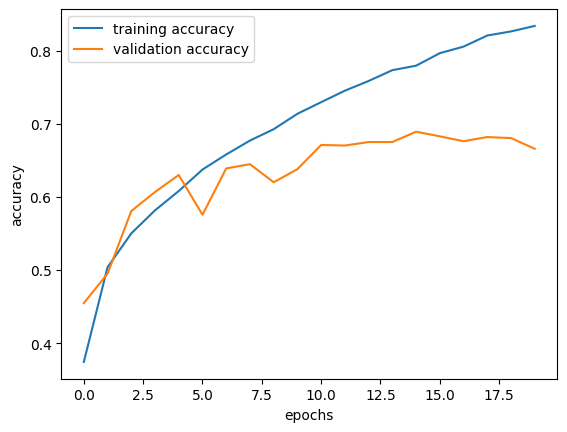

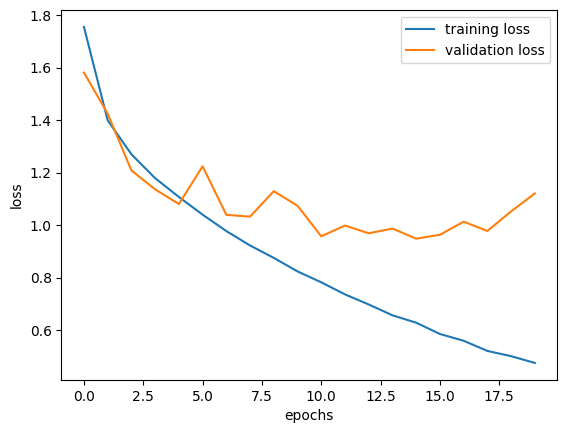

In [12]:
plt.plot(history.history['accuracy'],label='training accuracy')
plt.plot(history.history['val_accuracy'],label='validation accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'],label='training loss')
plt.plot(history.history['val_loss'],label='validation loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

### evaluate the model

In [13]:
score = model.evaluate(
    X_test, Y_test, 
    batch_size=BATCH_SIZE, 
    verbose=VERBOSE
)

print("Test score: ", score[0])
print("Test accuracy: ", score[1])

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6546 - loss: 1.1363
Test score:  1.1363459825515747
Test accuracy:  0.6546000242233276


### using tensorboard
tensorboard --host 0.0.0.0 --logdir logs/cifar10/scalars

